In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import copy

# ------------------------
# PARAMETERS
# ------------------------
WIDTH = 380
HEIGHT = 280
NUM_VOTERS = 1000       # Can change
NUM_PARTIES = 3         # Can change
NUM_DISTRICTS = 8
VOTERS_PER_DISTRICT = NUM_VOTERS // NUM_DISTRICTS
NUM_RUNS = 10           # Number of redistricting simulations

NUM_CITIES = 5
CITY_INTENSITY = (5, 12)
CITY_SPREAD = (10, 30)

np.random.seed(1)

PARTY_IDS = [f"Party {i}" for i in range(NUM_PARTIES)]
party_colors = np.random.rand(NUM_PARTIES, 3)
PARTY_COLORS = dict(zip(PARTY_IDS, party_colors))

# ------------------------
# GENERATE POPULATION DENSITY
# ------------------------
density = np.full((HEIGHT, WIDTH), 1.0)
X, Y = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))

for _ in range(NUM_CITIES):
    cx = np.random.uniform(0, WIDTH)
    cy = np.random.uniform(0, HEIGHT)
    intensity = np.random.uniform(*CITY_INTENSITY)
    sigma = np.random.uniform(*CITY_SPREAD)
    density += intensity * np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma**2))

# ------------------------
# GENERATE VOTERS BASED ON DENSITY
# ------------------------
flat_density = density.ravel()
flat_density /= flat_density.sum()
indices = np.random.choice(WIDTH * HEIGHT, size=NUM_VOTERS, p=flat_density)
voters_y, voters_x = np.unravel_index(indices, (HEIGHT, WIDTH))
voters = np.column_stack((voters_x, voters_y))

# ------------------------
# FIXED PARTY PREFERENCES
# ------------------------
voter_parties = np.random.randint(0, NUM_PARTIES, NUM_VOTERS)
voter_colors = party_colors[voter_parties]
def connected_districts(voters, num_districts, voters_per_district, k_neighbors=20):
    N = len(voters)
    district = -np.ones(N, dtype=int)
    tree = cKDTree(voters)
    unassigned = set(range(N))

    # Create districts with BFS
    for d in range(num_districts):
        if not unassigned:
            break

        seed = np.random.choice(list(unassigned))
        district[seed] = d
        unassigned.remove(seed)
        queue = [seed]
        count = 1

        while queue and count < voters_per_district:
            current = queue.pop(0)
            _, neighbors = tree.query(voters[current], k=k_neighbors)

            for n in neighbors:
                if n in unassigned:
                    district[n] = d
                    unassigned.remove(n)
                    queue.append(n)
                    count += 1
                    if count >= voters_per_district:
                        break

        # Retry if district incomplete
        if count < voters_per_district:
            for i in range(N):
                if district[i] == d:
                    district[i] = -1
                    unassigned.add(i)
            return connected_districts(voters, num_districts, voters_per_district)

    # ------------------------
    # Assign leftover voters to nearest district
    # ------------------------
    leftover_indices = np.where(district == -1)[0]
    assigned_indices = np.where(district != -1)[0]

    if len(leftover_indices) > 0:
        assigned_tree = cKDTree(voters[assigned_indices])
        for i in leftover_indices:
            _, idx = assigned_tree.query(voters[i])
            nearest_assigned = assigned_indices[idx]
            district[i] = district[nearest_assigned]

    return district
# ------------------------
# COUNT VOTES
# ------------------------
def count_votes(district_labels):
    district_counts = []
    for d in range(NUM_DISTRICTS):
        mask = district_labels == d
        counts = {party: 0 for party in PARTY_IDS}
        for i in np.where(mask)[0]:
            counts[PARTY_IDS[voter_parties[i]]] += 1
        district_counts.append(counts)
    return district_counts


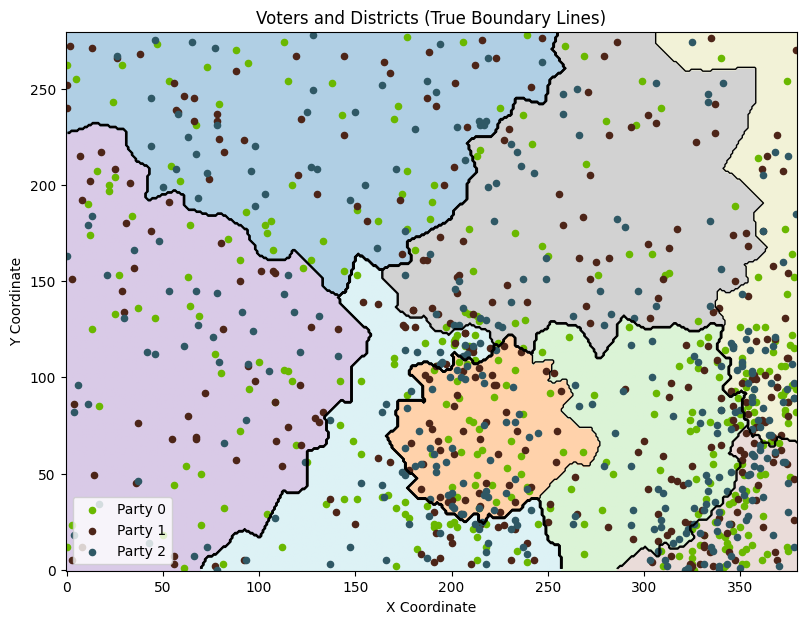

In [18]:
# ------------------------
# VISUALIZE ONE RUN (NO OVERLAP)
# ------------------------

district_labels = connected_districts(voters, NUM_DISTRICTS, VOTERS_PER_DISTRICT)

# Build KD-tree for fast nearest lookup
tree = cKDTree(voters)

# Create grid of every pixel
xx, yy = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))
grid_points = np.column_stack((xx.ravel(), yy.ravel()))

# Assign each pixel to nearest voter
_, nearest_voter = tree.query(grid_points)
pixel_districts = district_labels[nearest_voter]
pixel_map = pixel_districts.reshape((HEIGHT, WIDTH))

plt.figure(figsize=(10,7))

# Lightly color districts
plt.imshow(pixel_map, origin='lower', cmap='tab20', alpha=0.35)

# Draw district boundaries
plt.contour(
    pixel_map,
    levels=np.arange(NUM_DISTRICTS)+0.5,
    colors='black',
    linewidths=1,
    origin='lower'
)

# Plot voters on top
for i, party in enumerate(PARTY_IDS):
    mask = voter_parties == i
    plt.scatter(
        voters[mask,0],
        voters[mask,1],
        color=PARTY_COLORS[party],
        label=party,
        s=20
    )

plt.title("Voters and Districts (True Boundary Lines)")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend()
plt.show()

